In [55]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

client = bigquery.Client()

def run_query(query: str) -> pd.DataFrame:
    return client.query(query).to_dataframe()


plt.style.use("ggplot")

Using Kaggle's public dataset BigQuery integration.


In [56]:
FUNNEL_START = "20170701"
FUNNEL_END   = "20170731"

RETENTION_START = "20170601"
RETENTION_END   = "20170831"

LTV_START = "20170301"
LTV_END   = "20170831"

In [57]:
query_funnel = f"""
WITH session_level AS (
  SELECT
    CONCAT(fullVisitorId, '-', CAST(visitId AS STRING)) AS session_id,

    MAX(
      CASE
        WHEN hits.type = 'PAGE'
         AND hits.page.pagePath IS NOT NULL
         AND (
              LOWER(hits.page.pagePath) LIKE '/google+redesign/%'
              OR LOWER(hits.page.pagePath) LIKE '%/quickview%'
             )
         AND LOWER(hits.page.pagePath) <> '/home'
         AND LOWER(hits.page.pagePath) NOT LIKE '%shop+by+brand%'
        THEN 1 ELSE 0
      END
    ) AS has_product_page,

    MAX(
      CASE
        WHEN hits.type = 'PAGE'
         AND hits.page.pagePath IS NOT NULL
         AND LOWER(hits.page.pagePath) LIKE '%basket%'
        THEN 1 ELSE 0
      END
    ) AS has_cart,

    MAX(
      CASE
        WHEN hits.type = 'PAGE'
         AND hits.page.pagePath IS NOT NULL
         AND (
              LOWER(hits.page.pagePath) LIKE '%yourinfo%'
              OR LOWER(hits.page.pagePath) LIKE '%payment%'
              OR LOWER(hits.page.pagePath) LIKE '%revieworder%'
             )
        THEN 1 ELSE 0
      END
    ) AS has_checkout,

    MAX(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END) AS has_purchase

  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
  UNNEST(hits) AS hits
  WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
  GROUP BY session_id
)

SELECT
  COUNT(*) AS sessions,
  SUM(has_product_page) AS sessions_with_product_page,
  SUM(has_cart) AS sessions_with_cart,
  SUM(has_checkout) AS sessions_with_checkout,
  SUM(has_purchase) AS sessions_with_purchase,

  SAFE_DIVIDE(SUM(has_product_page), COUNT(*)) AS cr_session_to_product,
  SAFE_DIVIDE(SUM(has_cart), SUM(has_product_page)) AS cr_product_to_cart,
  SAFE_DIVIDE(SUM(has_checkout), SUM(has_cart)) AS cr_cart_to_checkout,
  SAFE_DIVIDE(SUM(has_purchase), SUM(has_checkout)) AS cr_checkout_to_purchase,
  SAFE_DIVIDE(SUM(has_purchase), COUNT(*)) AS cr_session_to_purchase
FROM session_level
"""
df_funnel = run_query(query_funnel)
df_funnel

,sessions,sessions_with_product_page,sessions_with_cart,sessions_with_checkout,sessions_with_purchase,cr_session_to_product,cr_product_to_cart,cr_cart_to_checkout,cr_checkout_to_purchase,cr_session_to_purchase
0,71708,32268,5871,2193,1031,0.449992,0.181945,0.373531,0.470132,0.014378


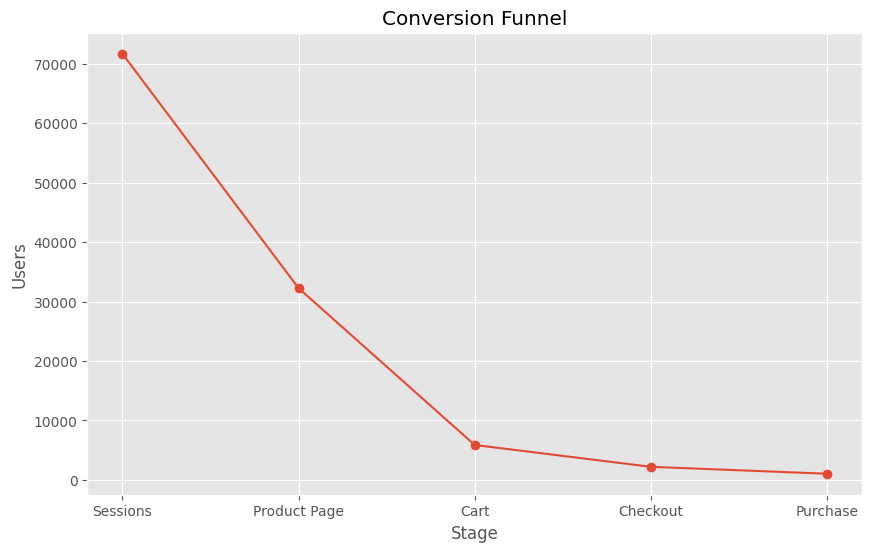

In [58]:
stages = [
    "Sessions",
    "Product Page",
    "Cart",
    "Checkout",
    "Purchase"
]

values = [
    df_funnel["sessions"][0],
    df_funnel["sessions_with_product_page"][0],
    df_funnel["sessions_with_cart"][0],
    df_funnel["sessions_with_checkout"][0],
    df_funnel["sessions_with_purchase"][0]
]

plt.figure(figsize=(10,6))
plt.plot(stages, values, marker='o')
plt.title("Conversion Funnel")
plt.xlabel("Stage")
plt.ylabel("Users")
plt.grid(True)
plt.show()

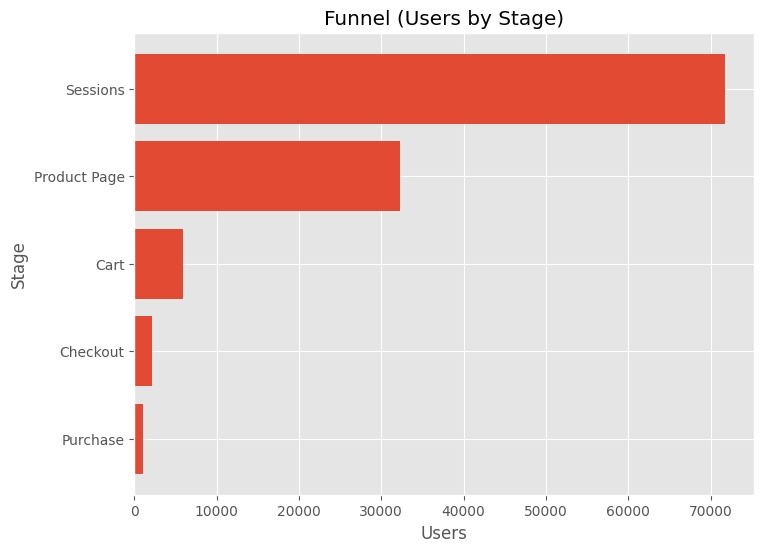

In [59]:
plt.figure(figsize=(8,6))

plt.barh(stages[::-1], values[::-1])

plt.title("Funnel (Users by Stage)")
plt.xlabel("Users")
plt.ylabel("Stage")

plt.show()

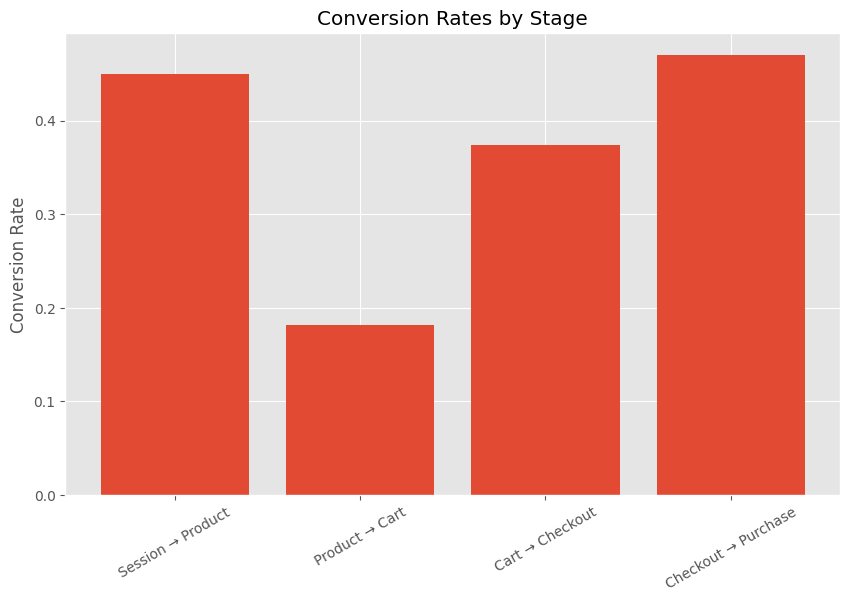

In [60]:
conversion = [
    df_funnel["cr_session_to_product"][0],
    df_funnel["cr_product_to_cart"][0],
    df_funnel["cr_cart_to_checkout"][0],
    df_funnel["cr_checkout_to_purchase"][0]
]

labels = [
    "Session → Product",
    "Product → Cart",
    "Cart → Checkout",
    "Checkout → Purchase"
]

plt.figure(figsize=(10,6))
plt.bar(labels, conversion)
plt.title("Conversion Rates by Stage")
plt.ylabel("Conversion Rate")

plt.xticks(rotation=30)
plt.show()

### самое узкое место: product → cart (18%)

In [61]:
query_pages = f"""
SELECT
  hits.page.pagePath AS page_path,
  COUNT(*) AS pageviews,
  COUNT(DISTINCT fullVisitorId) AS unique_users,
  COUNT(DISTINCT CONCAT(fullVisitorId, '-', CAST(visitId AS STRING))) AS unique_sessions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits
WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
  AND hits.type = 'PAGE'
  AND hits.page.pagePath IS NOT NULL
GROUP BY page_path
ORDER BY pageviews DESC
LIMIT 100
"""
df_pages = run_query(query_pages)
df_pages.head(20)

,page_path,pageviews,unique_users,unique_sessions
0,/home,61698,33342,39434
1,/google+redesign/shop+by+brand/youtube,22205,17605,18569
2,/basket.html,15629,4790,5860
3,/google+redesign/apparel/mens/mens+t+shirts,8625,5991,6677
4,/signin.html,8253,4218,5425
5,/asearch.html,5538,3610,3900
6,/store.html,5311,3208,3717
7,/google+redesign/bags,4472,3205,3491
8,/google+redesign/apparel,4457,3100,3378
9,/google+redesign/electronics,4294,3265,3469


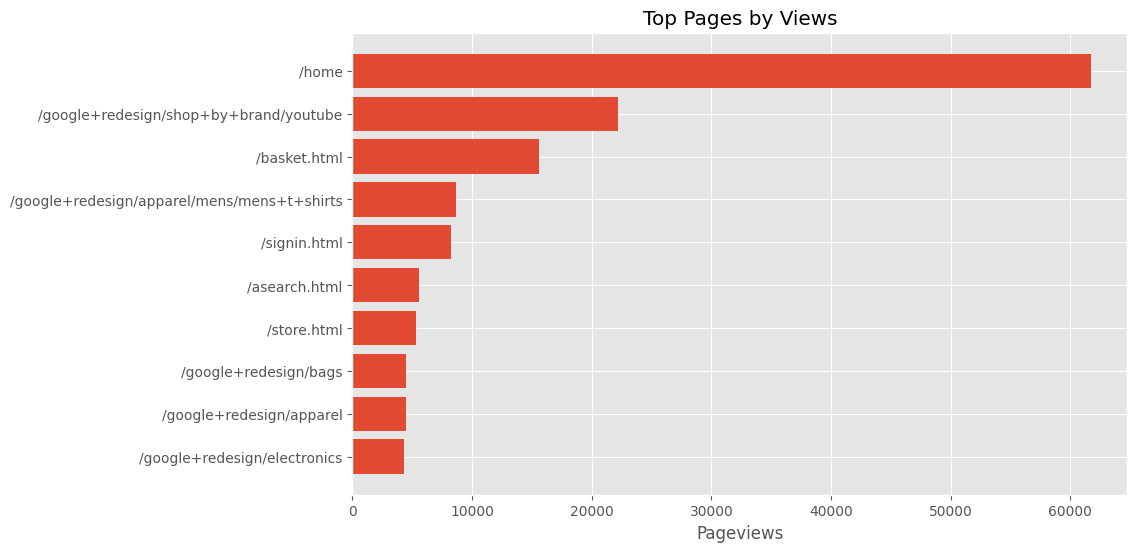

In [62]:
top_pages = df_pages.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_pages["page_path"], top_pages["pageviews"])

plt.title("Top Pages by Views")
plt.xlabel("Pageviews")

plt.gca().invert_yaxis()
plt.show()

In [63]:
query_user_journey = f"""
SELECT
  fullVisitorId,
  visitId,
  visitNumber,
  hits.hitNumber AS hit_number,
  hits.page.pagePath AS page_path
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
UNNEST(hits) AS hits
WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
  AND hits.type = 'PAGE'
  AND hits.page.pagePath IS NOT NULL
ORDER BY fullVisitorId, visitId, hit_number
LIMIT 2000
"""
df_user_journey = run_query(query_user_journey)
df_user_journey.head(30)

,fullVisitorId,visitId,visitNumber,hit_number,page_path
0,0000062267706107999,1499645960,1,1,/home
1,0000085059828173212,1500505105,1,1,/asearch.html
2,0000436683523507380,1500504900,1,1,/home
3,0000436683523507380,1500504900,1,2,/google+redesign/electronics/power/clip+compac...
4,0000436683523507380,1500989127,2,1,/home
5,0000436683523507380,1500989127,2,2,/google+redesign/bags/backpacks/waterproof+bac...
6,0000436683523507380,1500989127,2,3,/home
7,0000436683523507380,1500989127,2,4,/home
8,0000436683523507380,1500989127,2,5,/google+redesign/electronics
9,0000436683523507380,1500989127,2,6,/google+redesign/office/notebooks+journals/goo...


In [64]:
query_channels = f"""
SELECT
  trafficSource.source AS source,
  trafficSource.medium AS medium,
  COUNT(*) AS sessions,
  COUNT(DISTINCT fullVisitorId) AS users,
  SUM(IFNULL(totals.transactions, 0)) AS transactions,
  SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0 AS revenue,
  SAFE_DIVIDE(
    SUM(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END),
    COUNT(*)
  ) AS conversion_rate,
  SAFE_DIVIDE(
    SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0,
    COUNT(*)
  ) AS revenue_per_session
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
GROUP BY source, medium
HAVING COUNT(*) >= 100
ORDER BY sessions DESC
"""
df_channels = run_query(query_channels)
df_channels.head(20)

,source,medium,sessions,users,transactions,revenue,conversion_rate,revenue_per_session
0,google,organic,36007,31083,296,24742.16,0.008082,0.687149
1,(direct),(none),19890,15424,684,93330.93,0.032831,4.692354
2,youtube.com,referral,6351,5986,1,3.49,0.000157,0.000550
3,google,cpc,2008,1580,48,3413.70,0.022410,1.700050
4,analytics.google.com,referral,1972,1501,0,0.00,0.000000,0.000000
5,Partners,affiliate,1788,1479,4,487.71,0.002237,0.272768
6,m.facebook.com,referral,669,644,1,2.99,0.001495,0.004469
7,google,cpm,384,295,16,1188.79,0.039062,3.095807
8,google.com,referral,368,330,0,0.00,0.000000,0.000000
9,dfa,cpm,302,207,5,416.14,0.013245,1.377947


### По каналам видно сильное различие в качестве трафика. Direct конвертится примерно в 3.3%, Google — около 0.9%. По выручке на сессию разрыв такой же: 4.69 против 0.69. То есть direct-трафик даёт в несколько раз больше ценности. Скорее всего, это лояльные или уже знакомые с продуктом пользователи, тогда как Google приводит холодный трафик. Проблема в том, что основной объём идёт именно из Google, но он почти не монетизируется.

In [67]:
query_conversion_channels = f"""
SELECT
  trafficSource.source AS source,
  COUNT(*) AS sessions,
  SUM(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END) AS sessions_with_transaction,
  SAFE_DIVIDE(
    SUM(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END),
    COUNT(*)
  ) AS conversion_rate,
  SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0 AS revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
GROUP BY source
HAVING COUNT(*) >= 100
ORDER BY conversion_rate DESC
"""
df_conversion_channels = run_query(query_conversion_channels)
df_conversion_channels.head(20)

,source,sessions,sessions_with_transaction,conversion_rate,revenue
0,(direct),19891,653,0.032829,93330.93
1,sites.google.com,230,7,0.030435,465.96
2,yahoo,100,3,0.030000,142.61
3,mail.google.com,101,3,0.029703,175.63
4,bing,111,2,0.018018,44.94
5,dfa,302,4,0.013245,416.14
6,google,38400,351,0.009141,29344.65
7,Partners,1788,4,0.002237,487.71
8,m.facebook.com,669,1,0.001495,2.99
9,youtube.com,6351,1,0.000157,3.49


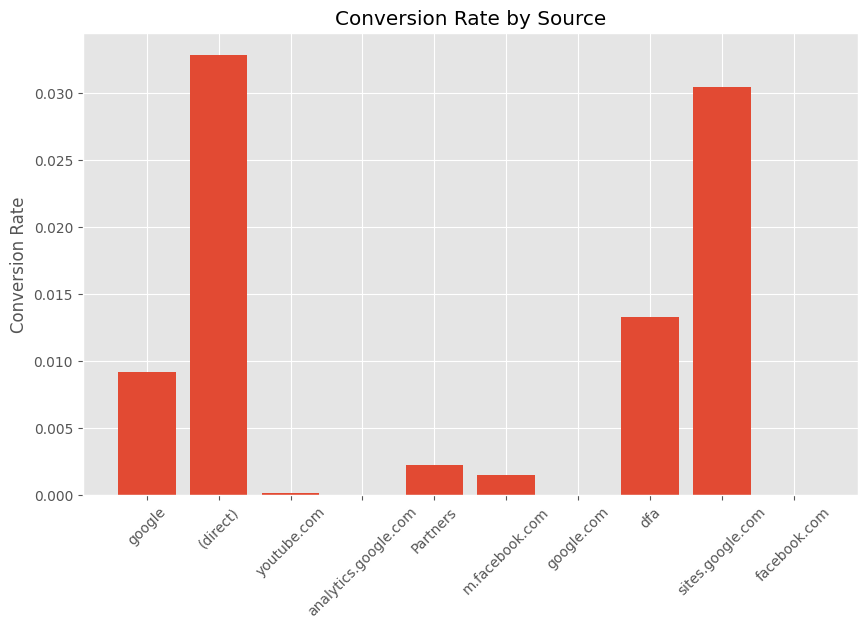

In [68]:
top_channels = df_conversion_channels.sort_values("sessions", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top_channels["source"], top_channels["conversion_rate"])

plt.title("Conversion Rate by Source")
plt.xticks(rotation=45)
plt.ylabel("Conversion Rate")

plt.show()

In [69]:
query_conversion_device = f"""
SELECT
  device.deviceCategory AS device_category,
  COUNT(*) AS sessions,
  SUM(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END) AS sessions_with_transaction,
  SAFE_DIVIDE(
    SUM(CASE WHEN IFNULL(totals.transactions, 0) > 0 THEN 1 ELSE 0 END),
    COUNT(*)
  ) AS conversion_rate,
  SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0 AS revenue,
  SAFE_DIVIDE(
    SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0,
    COUNT(*)
  ) AS revenue_per_session
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '{FUNNEL_START}' AND '{FUNNEL_END}'
GROUP BY device_category
ORDER BY conversion_rate DESC
"""
df_conversion_device = run_query(query_conversion_device)
df_conversion_device

,device_category,sessions,sessions_with_transaction,conversion_rate,revenue,revenue_per_session
0,desktop,45595,926,0.020309,117700.02,2.581424
1,tablet,3110,13,0.004180,494.15,0.158891
2,mobile,23107,92,0.003981,6305.11,0.272866


### desktop конвертится примерно в 2%, mobile — около 0.4%. Разница примерно в 5 раз. Это прямой сигнал, что с мобильной версией что-то не так — либо UX, либо скорость, либо сам процесс покупки неудобный.

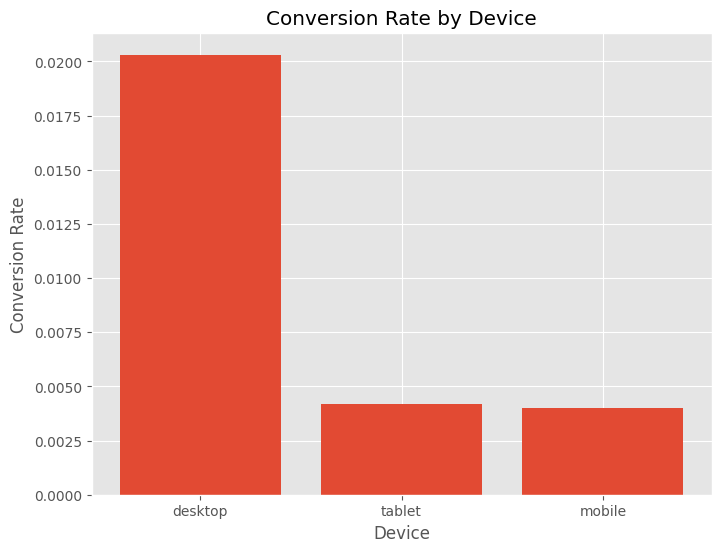

In [70]:
plt.figure(figsize=(8,6))
plt.bar(df_conversion_device["device_category"], df_conversion_device["conversion_rate"])

plt.title("Conversion Rate by Device")
plt.xlabel("Device")
plt.ylabel("Conversion Rate")

plt.show()

In [71]:
query_retention = f"""
WITH visits AS (
  SELECT DISTINCT
    fullVisitorId,
    PARSE_DATE('%Y%m%d', date) AS visit_date
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  WHERE _TABLE_SUFFIX BETWEEN '{RETENTION_START}' AND '{RETENTION_END}'
),

first_visits AS (
  SELECT
    fullVisitorId,
    MIN(visit_date) AS cohort_date
  FROM visits
  GROUP BY fullVisitorId
),

activity AS (
  SELECT
    fv.fullVisitorId,
    fv.cohort_date,
    DATE_DIFF(v.visit_date, fv.cohort_date, DAY) AS days_since_first
  FROM first_visits fv
  JOIN visits v
    ON fv.fullVisitorId = v.fullVisitorId
),

max_date AS (
  SELECT MAX(PARSE_DATE('%Y%m%d', date)) AS data_end_date
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  WHERE _TABLE_SUFFIX BETWEEN '{RETENTION_START}' AND '{RETENTION_END}'
)

SELECT
  a.cohort_date,
  COUNT(DISTINCT a.fullVisitorId) AS cohort_size,

  COUNT(DISTINCT CASE WHEN a.days_since_first = 1 THEN a.fullVisitorId END) AS retained_d1,
  COUNT(DISTINCT CASE WHEN a.days_since_first = 7 THEN a.fullVisitorId END) AS retained_d7,
  COUNT(DISTINCT CASE WHEN a.days_since_first = 30 THEN a.fullVisitorId END) AS retained_d30,

  SAFE_DIVIDE(
    COUNT(DISTINCT CASE WHEN a.days_since_first = 1 THEN a.fullVisitorId END),
    COUNT(DISTINCT a.fullVisitorId)
  ) AS retention_d1,

  SAFE_DIVIDE(
    COUNT(DISTINCT CASE WHEN a.days_since_first = 7 THEN a.fullVisitorId END),
    COUNT(DISTINCT a.fullVisitorId)
  ) AS retention_d7,

  SAFE_DIVIDE(
    COUNT(DISTINCT CASE WHEN a.days_since_first = 30 THEN a.fullVisitorId END),
    COUNT(DISTINCT a.fullVisitorId)
  ) AS retention_d30

FROM activity a
CROSS JOIN max_date m
WHERE DATE_DIFF(m.data_end_date, a.cohort_date, DAY) >= 30
GROUP BY a.cohort_date
ORDER BY a.cohort_date
"""
df_retention = run_query(query_retention)
df_retention.head()

,cohort_date,cohort_size,retained_d1,retained_d7,retained_d30,retention_d1,retention_d7,retention_d30
0,2017-06-01,2599,103,43,5,0.039631,0.016545,0.001924
1,2017-06-02,1948,39,20,2,0.020021,0.010267,0.001027
2,2017-06-03,1214,40,7,3,0.032949,0.005766,0.002471
3,2017-06-04,1343,48,7,5,0.035741,0.005212,0.003723
4,2017-06-05,2078,77,30,6,0.037055,0.014437,0.002887


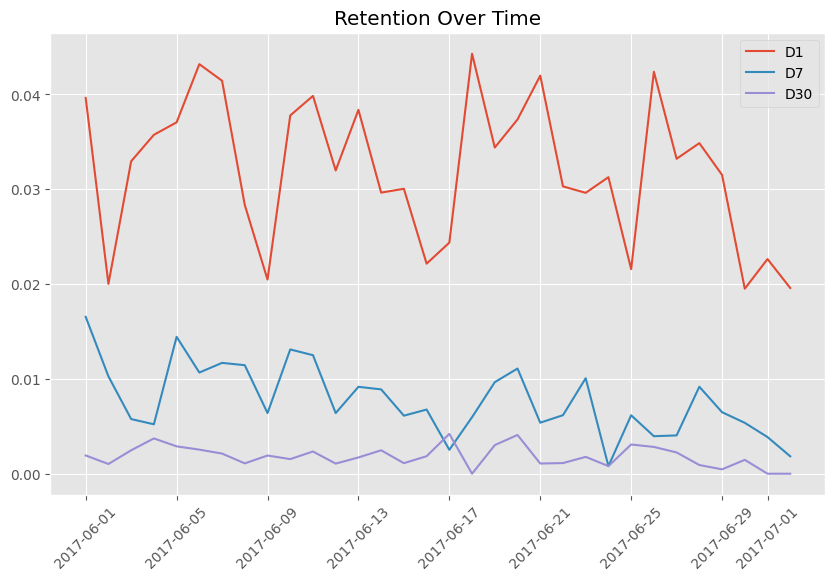

In [72]:
plt.figure(figsize=(10,6))

plt.plot(df_retention["cohort_date"], df_retention["retention_d1"])
plt.plot(df_retention["cohort_date"], df_retention["retention_d7"])
plt.plot(df_retention["cohort_date"], df_retention["retention_d30"])

plt.legend(["D1", "D7", "D30"])
plt.title("Retention Over Time")
plt.xticks(rotation=45)

plt.show()

### Retention очень низкий: D1 около 2–4%, D7 уже меньше 1–1.5%, D30 почти ноль. Для e-commerce это наверное нормально

In [73]:
query_churn = f"""
WITH visits AS (
  SELECT DISTINCT
    fullVisitorId,
    PARSE_DATE('%Y%m%d', date) AS visit_date
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  WHERE _TABLE_SUFFIX BETWEEN '{RETENTION_START}' AND '{RETENTION_END}'
),

date_bounds AS (
  SELECT
    MIN(visit_date) AS min_date,
    MAX(visit_date) AS max_date
  FROM visits
),

user_flags AS (
  SELECT
    v.fullVisitorId,
    MAX(CASE
          WHEN v.visit_date BETWEEN d.min_date AND DATE_ADD(d.min_date, INTERVAL 29 DAY)
          THEN 1 ELSE 0
        END) AS active_early,
    MAX(CASE
          WHEN v.visit_date BETWEEN DATE_SUB(d.max_date, INTERVAL 13 DAY) AND d.max_date
          THEN 1 ELSE 0
        END) AS active_late
  FROM visits v
  CROSS JOIN date_bounds d
  GROUP BY v.fullVisitorId
)

SELECT
  COUNTIF(active_early = 1) AS users_in_base,
  COUNTIF(active_early = 1 AND active_late = 0) AS churned_users,
  SAFE_DIVIDE(
    COUNTIF(active_early = 1 AND active_late = 0),
    COUNTIF(active_early = 1)
  ) AS churn_rate
FROM user_flags
"""
df_churn = run_query(query_churn)
df_churn

,users_in_base,churned_users,churn_rate
0,52067,51157,0.982523


### Churn получается около 98%

In [74]:
query_ltv = f"""
SELECT
  fullVisitorId,
  COUNT(*) AS total_sessions,
  SUM(IFNULL(totals.transactions, 0)) AS total_transactions,
  SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0 AS total_revenue
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '{LTV_START}' AND '{LTV_END}'
GROUP BY fullVisitorId
ORDER BY total_revenue DESC
"""
df_ltv = run_query(query_ltv)
df_ltv.head()

,fullVisitorId,total_sessions,total_transactions,total_revenue
0,1957458976293878100,124,21,59257.93
1,9417857471295131045,16,9,15170.12
2,4471415710206918415,16,3,10452.10
3,79204932396995037,8,2,7047.15
4,9026840718082010040,28,7,6906.38


In [75]:
df_ltv["total_revenue"].mean()

np.float64(2.493468073234394)

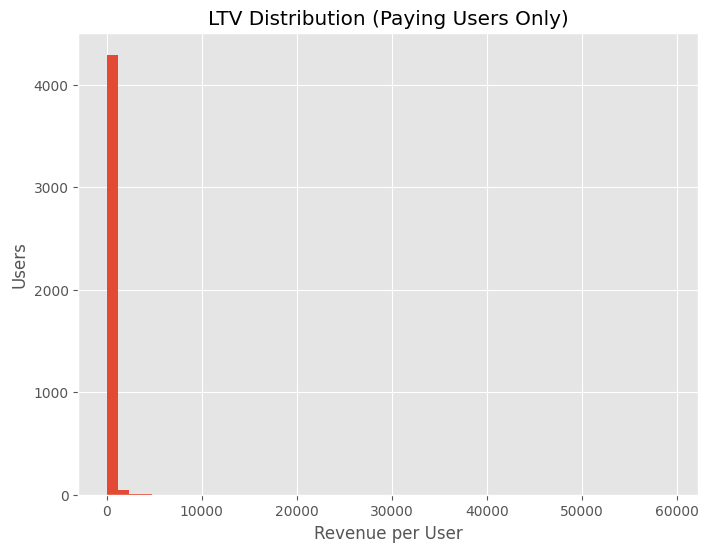

In [77]:
paying = df_ltv[df_ltv["total_revenue"] > 0]

plt.figure(figsize=(8,6))
plt.hist(paying["total_revenue"], bins=50)

plt.title("LTV Distribution (Paying Users Only)")
plt.xlabel("Revenue per User")
plt.ylabel("Users")

plt.show()

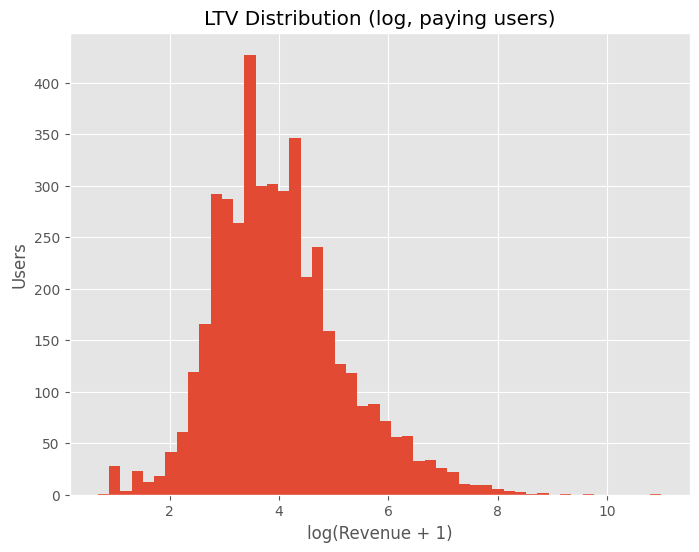

In [76]:
paying = df_ltv[df_ltv["total_revenue"] > 0]

plt.figure(figsize=(8,6))
plt.hist(np.log1p(paying["total_revenue"]), bins=50)

plt.title("LTV Distribution (log, paying users)")
plt.xlabel("log(Revenue + 1)")
plt.ylabel("Users")

plt.show()

### По LTV видно сильное перекошенное распределение: средний около 2.5, но есть отдельные пользователи с очень большим вкладом. То есть основную выручку даёт небольшая группа “китов”, а большинство почти ничего не приносит.

In [78]:
query_ltv_first_touch = f"""
WITH sessions AS (
  SELECT
    fullVisitorId,
    PARSE_DATE('%Y%m%d', date) AS visit_date,
    visitStartTime,
    trafficSource.source AS source,
    IFNULL(totals.transactionRevenue, 0) / 1000000.0 AS revenue
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  WHERE _TABLE_SUFFIX BETWEEN '{LTV_START}' AND '{LTV_END}'
),

first_touch AS (
  SELECT
    fullVisitorId,
    ARRAY_AGG(source ORDER BY visit_date, visitStartTime LIMIT 1)[OFFSET(0)] AS first_source
  FROM sessions
  GROUP BY fullVisitorId
),

user_revenue AS (
  SELECT
    fullVisitorId,
    SUM(revenue) AS total_revenue
  FROM sessions
  GROUP BY fullVisitorId
)

SELECT
  ft.first_source AS source,
  COUNT(*) AS users,
  AVG(ur.total_revenue) AS avg_ltv,
  SUM(ur.total_revenue) AS total_revenue
FROM first_touch ft
JOIN user_revenue ur
  ON ft.fullVisitorId = ur.fullVisitorId
GROUP BY source
HAVING COUNT(*) >= 50
ORDER BY total_revenue DESC
"""
df_ltv_first_touch = run_query(query_ltv_first_touch)
df_ltv_first_touch.head(20)

,source,users,avg_ltv,total_revenue
0,(direct),85721,5.996780,514049.99
1,google,126599,1.094935,138617.62
2,dfa,316,15.425949,4874.60
3,mail.google.com,205,12.981512,2661.21
4,groups.google.com,313,2.795112,874.87
5,sites.google.com,614,0.857606,526.57
6,Partners,5540,0.091457,506.67
7,bing,701,0.659087,462.02
8,yahoo,724,0.618246,447.61
9,l.facebook.com,317,1.148486,364.07


### Если смотреть LTV по каналам, картина та же: direct сильно лучше Google и по среднему чеку, и по общей выручке. В итоге получается, что бизнес по сути держится на direct-трафике, а масштабирование через поисковый трафик пока не даёт сопоставимого эффекта.

In [79]:
query_revenue_by_source = f"""
SELECT
  trafficSource.source AS source,
  COUNT(*) AS sessions,
  COUNT(DISTINCT fullVisitorId) AS users,
  SUM(IFNULL(totals.transactions, 0)) AS transactions,
  SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0 AS revenue,
  SAFE_DIVIDE(
    SUM(IFNULL(totals.transactionRevenue, 0)) / 1000000.0,
    COUNT(*)
  ) AS revenue_per_session
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
WHERE _TABLE_SUFFIX BETWEEN '{LTV_START}' AND '{LTV_END}'
GROUP BY source
HAVING COUNT(*) >= 100
ORDER BY revenue DESC
"""
df_revenue_by_source = run_query(query_revenue_by_source)
df_revenue_by_source.head(20)

,source,sessions,users,transactions,revenue,revenue_per_session
0,(direct),116103,87889,3511,450621.91,3.881225
1,google,157233,129699,1482,137442.69,0.874134
2,dfa,1542,945,39,63643.07,41.273067
3,mail.google.com,574,328,30,5809.83,10.121655
4,sites.google.com,958,696,14,1646.55,1.718737
5,groups.google.com,512,396,31,1389.42,2.713711
6,dealspotr.com,105,82,7,1385.70,13.197143
7,yahoo,838,744,12,788.19,0.940561
8,l.facebook.com,494,381,26,630.91,1.277146
9,bing,885,729,11,542.84,0.613379


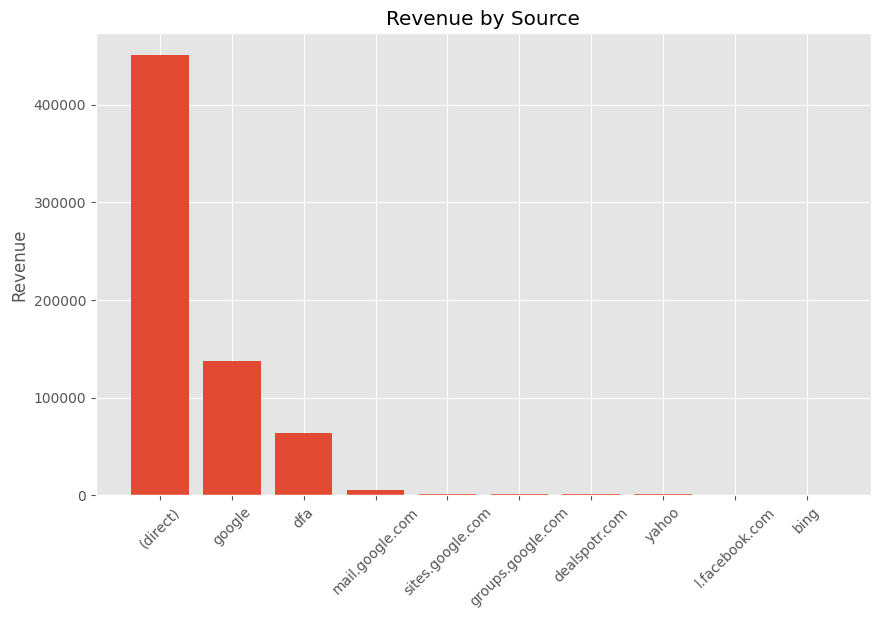

In [80]:
top_rev = df_revenue_by_source.head(10)

plt.figure(figsize=(10,6))
plt.bar(top_rev["source"], top_rev["revenue"])

plt.title("Revenue by Source")
plt.xticks(rotation=45)
plt.ylabel("Revenue")

plt.show()

## Если суммировать, основные проблемы — это слабая конверсия на этапе product → cart, очень плохая конверсия на mobile и низкое качество SEO-трафика. При этом сильные стороны — это качественный direct-трафик, нормально работающий checkout и наличие пользователей с высоким LTV.